# Milestone 2: Initial Implementation - Competitive Pokémon TCG Data Mining
**Author:** Axel Alvarez
**Course:** CS 4412: Data Mining

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json

In [9]:
import requests
import pandas as pd

# The base URL from the Limitless API
BASE_URL = "https://play.limitlesstcg.com/api"

def fetch_tournament_standings(tournament_id):
    """Fetches decklist data for a specific tournament without an API key."""
    url = f"{BASE_URL}/tournaments/{tournament_id}/standings"

    print(f"Fetching data from: {url}...")
    response = requests.get(url)

    if response.status_code == 200:
        print("Success! Data retrieved.")
        return response.json()
    elif response.status_code == 429:
        print("Error 429: Rate limit hit. We will need to slow down the requests.")
        return None
    else:
        print(f"Error {response.status_code}: Could not retrieve data.")
        return None

# Using the exact slug from your URL
test_id = "69954a06c9dc8186f760750c"
raw_data = fetch_tournament_standings(test_id)

# Load it into a pandas DataFrame and take a look
if raw_data:
    df = pd.DataFrame(raw_data)
    display(df.head())

Fetching data from: https://play.limitlesstcg.com/api/tournaments/69954a06c9dc8186f760750c/standings...
Success! Data retrieved.


,name,country,decklist,deck,placing,player,record,drop
0,William S,IS,"{'pokemon': [{'count': 2, 'set': 'PRE', 'numbe...","{'id': 'flareon-noctowl', 'name': 'Flareon Noc...",1,tapuwill,"{'wins': 10, 'losses': 1, 'ties': 1}",NaN
1,Oscar C,GT,"{'pokemon': [{'count': 4, 'set': 'SSP', 'numbe...","{'id': 'gholdengo-lunatone', 'name': 'Gholdeng...",2,kokashar,"{'wins': 9, 'losses': 3, 'ties': 0}",NaN
2,Keegan Wingate,US,"{'pokemon': [{'count': 4, 'set': 'SSP', 'numbe...","{'id': 'ceruledge-ex', 'name': 'Ceruledge', 'i...",3,rileytiger2,"{'wins': 9, 'losses': 1, 'ties': 1}",NaN
3,AltF4000000,None,"{'pokemon': [{'count': 4, 'set': 'TWM', 'numbe...","{'id': 'dragapult-dusknoir', 'name': 'Dragapul...",4,altf4000000,"{'wins': 8, 'losses': 2, 'ties': 1}",NaN
4,ihybleezy,US,"{'pokemon': [{'count': 3, 'set': 'MEG', 'numbe...","{'id': 'gardevoir-ex-sv', 'name': 'Gardevoir',...",5,ihybleezy,"{'wins': 7, 'losses': 2, 'ties': 1}",9.0


In [10]:
# Drop any rows where the decklist is missing or null
df_clean = df.dropna(subset=['decklist']).copy()

def flatten_and_normalize(deck_obj):
    """
    Extracts cards from the nested dictionary and normalizes their names.
    Returns a flat dictionary of {card_name: count}.
    """
    flat_deck = {}

    # The Limitless API usually separates cards into these three categories
    categories = ['pokemon', 'trainer', 'energy']

    # Check if the deck_obj is actually a dictionary before proceeding
    if isinstance(deck_obj, dict):
        for category in categories:
            if category in deck_obj and isinstance(deck_obj[category], list):
                for card in deck_obj[category]:
                    # Grab the card name and how many copies are in the deck
                    raw_name = card.get('name', 'Unknown')
                    count = card.get('count', 0)


                    # Clean up the variants so the algorithm treats them as the same card
                    if "Boss's Orders" in raw_name:
                        canonical_name = "Boss's Orders"
                    elif "Professor's Research" in raw_name:
                        canonical_name = "Professor's Research"
                    else:
                        canonical_name = raw_name

                    flat_deck[canonical_name] = flat_deck.get(canonical_name, 0) + count

    return flat_deck

# Apply the function to create a new column of flattened, clean decklists
df_clean['flat_deck'] = df_clean['decklist'].apply(flatten_and_normalize)

print("Original nested format:", df_clean.iloc[0]['decklist'])
print("\nFlattened and normalized format:", df_clean.iloc[0]['flat_deck'])

Original nested format: {'pokemon': [{'count': 2, 'set': 'PRE', 'number': '77', 'name': 'Hoothoot'}, {'count': 2, 'set': 'SCR', 'number': '114', 'name': 'Hoothoot'}, {'count': 4, 'set': 'SCR', 'number': '115', 'name': 'Noctowl'}, {'count': 2, 'set': 'PRE', 'number': '75', 'name': 'Eevee ex'}, {'count': 2, 'set': 'SCR', 'number': '118', 'name': 'Fan Rotom'}, {'count': 1, 'set': 'SSP', 'number': '143', 'name': 'Eevee'}, {'count': 2, 'set': 'PRE', 'number': '14', 'name': 'Flareon ex'}, {'count': 1, 'set': 'PRE', 'number': '6', 'name': 'Leafeon ex'}, {'count': 1, 'set': 'SSP', 'number': '86', 'name': 'Sylveon ex'}, {'count': 1, 'set': 'ASC', 'number': '142', 'name': 'Fezandipiti ex'}, {'count': 1, 'set': 'SCR', 'number': '128', 'name': 'Terapagos ex'}, {'count': 1, 'set': 'MEW', 'number': '151', 'name': 'Mew ex'}, {'count': 1, 'set': 'TWM', 'number': '64', 'name': 'Wellspring Mask Ogerpon ex'}, {'count': 1, 'set': 'JTG', 'number': '56', 'name': "Lillie's Clefairy ex"}, {'count': 1, 'set': 

In [11]:
import requests
import pandas as pd
import time

# --- STEP 1: AUTO-GET RECENT TOURNAMENT IDs ---
print("Step 1: Searching for recent PTCG Standard tournaments...")
tournaments_url = "https://play.limitlesstcg.com/api/tournaments"
query_params = {"game": "PTCG", "format": "standard"}

response = requests.get(tournaments_url, params=query_params)
if response.status_code != 200:
    print(f"Failed to get tournament list. Error: {response.status_code}")
else:
    # Get the list of the last 50 tournaments
    recent_tournaments = response.json()
    # Extract just the IDs into a list
    tournament_ids = [t['id'] for t in recent_tournaments]
    print(f"Found {len(tournament_ids)} tournaments to process.")

    # --- STEP 2: LOOP AND FETCH STANDINGS ---
    all_tournaments_list = []

    for t_id in tournament_ids:
        print(f"Fetching data for: {t_id}...")
        standings_url = f"https://play.limitlesstcg.com/api/tournaments/{t_id}/standings"

        try:
            standings_res = requests.get(standings_url)
            if standings_res.status_code == 200:
                raw_data = standings_res.json()
                if raw_data:
                    temp_df = pd.DataFrame(raw_data)
                    temp_df['tournament_id'] = t_id # Track source for EDA
                    all_tournaments_list.append(temp_df)
            elif standings_res.status_code == 429:
                print("Rate limit hit! Sleeping for 10 seconds...")
                time.sleep(10)
        except Exception as e:
            print(f"Skipping {t_id} due to error: {e}")

        # 2-second pause to respect API limits
        time.sleep(2)

    # --- STEP 3: CONSOLIDATE & PREPROCESS ---
    if all_tournaments_list:
        df_master = pd.concat(all_tournaments_list, ignore_index=True)
        print(f"\nPipeline Complete! Total raw rows collected: {len(df_master)}")

        # Preprocessing: Remove rows with hidden decklists (Missing Value Handling)
        df_clean = df_master.dropna(subset=['decklist']).copy()

        # Apply the flattening and normalization function we built earlier
        df_clean['flat_deck'] = df_clean['decklist'].apply(flatten_and_normalize)

        print(f"Rows after removing missing decklists: {len(df_clean)}")
        display(df_clean[['name', 'placing', 'flat_deck']].head()) # Changed 'placement' to 'placing'
    else:
        print("No data collected.")

Step 1: Searching for recent PTCG Standard tournaments...
Found 50 tournaments to process.
Fetching data for: 69a5d1ab265a204acd585820...
Fetching data for: 69a86785f39e6e70969fbacb...
Fetching data for: 69a9d6696a05f00a8c4a4d55...
Fetching data for: 69a5e050818e5fde7d8178a2...
Fetching data for: 69a4c691d92ee137f4d1db9e...
Fetching data for: 69aa07946a05f00a8c4a50f3...
Fetching data for: 69a8b5e46a05f00a8c4a4504...
Fetching data for: 69a8e3206a05f00a8c4a46c5...
Fetching data for: 69ac42466a05f00a8c4a6991...
Fetching data for: 69a8a849f39e6e70969fbeb7...
Fetching data for: 69a76f12f39e6e70969fb50d...
Fetching data for: 69a76d7a6a05f00a8c4a38a4...
Fetching data for: 69aaedcd6a05f00a8c4a581e...
Fetching data for: 69ab2e07f39e6e70969fd7e1...
Fetching data for: 69a9f4f6f39e6e70969fc9b5...
Fetching data for: 69a9f064f39e6e70969fc926...
Fetching data for: 696d5f3c9c739a2ff7bf310e...
Fetching data for: 69954a06c9dc8186f760750c...
Fetching data for: 69ab59886a05f00a8c4a5dda...
Fetching data fo

/tmp/ipykernel_21525/1491560408.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_master = pd.concat(all_tournaments_list, ignore_index=True)


,name,placing,flat_deck
0,014,1.0,"{'Abra': 4, 'Kadabra': 3, 'Alakazam': 3, 'Duns..."
1,cheinsomen,2.0,"{'N's Zorua': 4, 'N's Zoroark ex': 4, 'N's Zek..."
2,ZiniTCG,3.0,"{'Riolu': 3, 'Mega Lucario ex': 3, 'Froakie': ..."
3,Matías Prado,4.0,"{'Dreepy': 4, 'Drakloak': 4, 'Dragapult ex': 3..."
4,"Vicente ""MoeHawk"" Canales Loyola",5.0,"{'Munkidori': 4, 'Marnie's Impidimp': 3, 'Marn..."


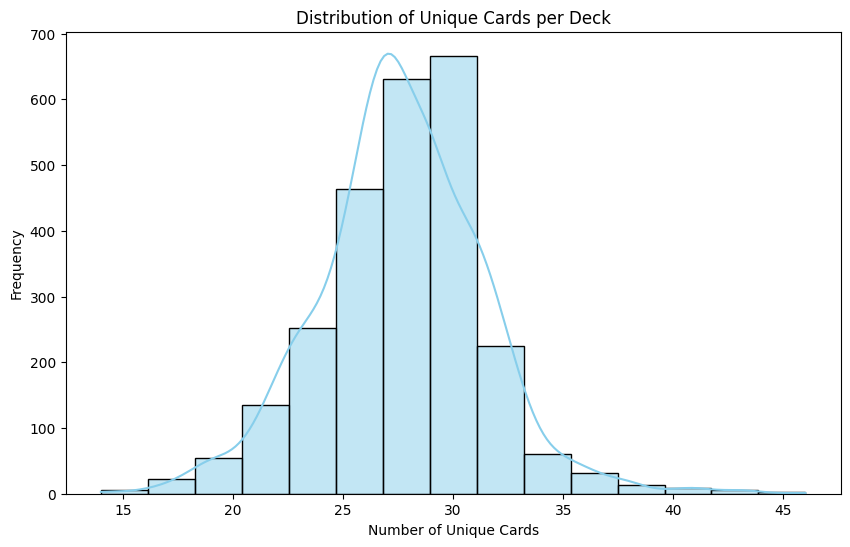

In [12]:
# Calculate number of unique cards per deck
df_clean['unique_card_count'] = df_clean['flat_deck'].apply(lambda x: len(x))

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['unique_card_count'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Unique Cards per Deck')
plt.xlabel('Number of Unique Cards')
plt.ylabel('Frequency')
plt.show()

**Interpretation: Deck Complexity (Unique Card Count)**

**Connection to Discovery Question:**

This visualization addresses the question of how to mathematically define the boundary between a deck's "Immutable Core" and its "Flex Slots". By analyzing the distribution of unique cards, I can establish a baseline for how much "room" typically exists for strategic variation within the 60-card limit.

**Purpose of Analysis:**

The purpose of this histogram is to understand the variance in deck "breadth". A highly concentrated distribution would suggest a rigid metagame where most players utilize the same number of unique items, whereas a wide distribution would indicate a meta where "Tech Choices" significantly alter the deck's structure.

**Insight & Discovery:**



*   Central Tendency: The distribution is roughly bell-shaped, peaking between 25 and 30 unique cards. This suggests that the average "Standard Format" engine requires about half of its 60 cards to be unique IDs to function.
*   Metadata Consistency: The tight grouping between 23 and 33 unique cards reveals that most competitive decks follow a very similar structural "recipe," supporting the hypothesis that a strong "Immutable Core" exists for almost every archetype.


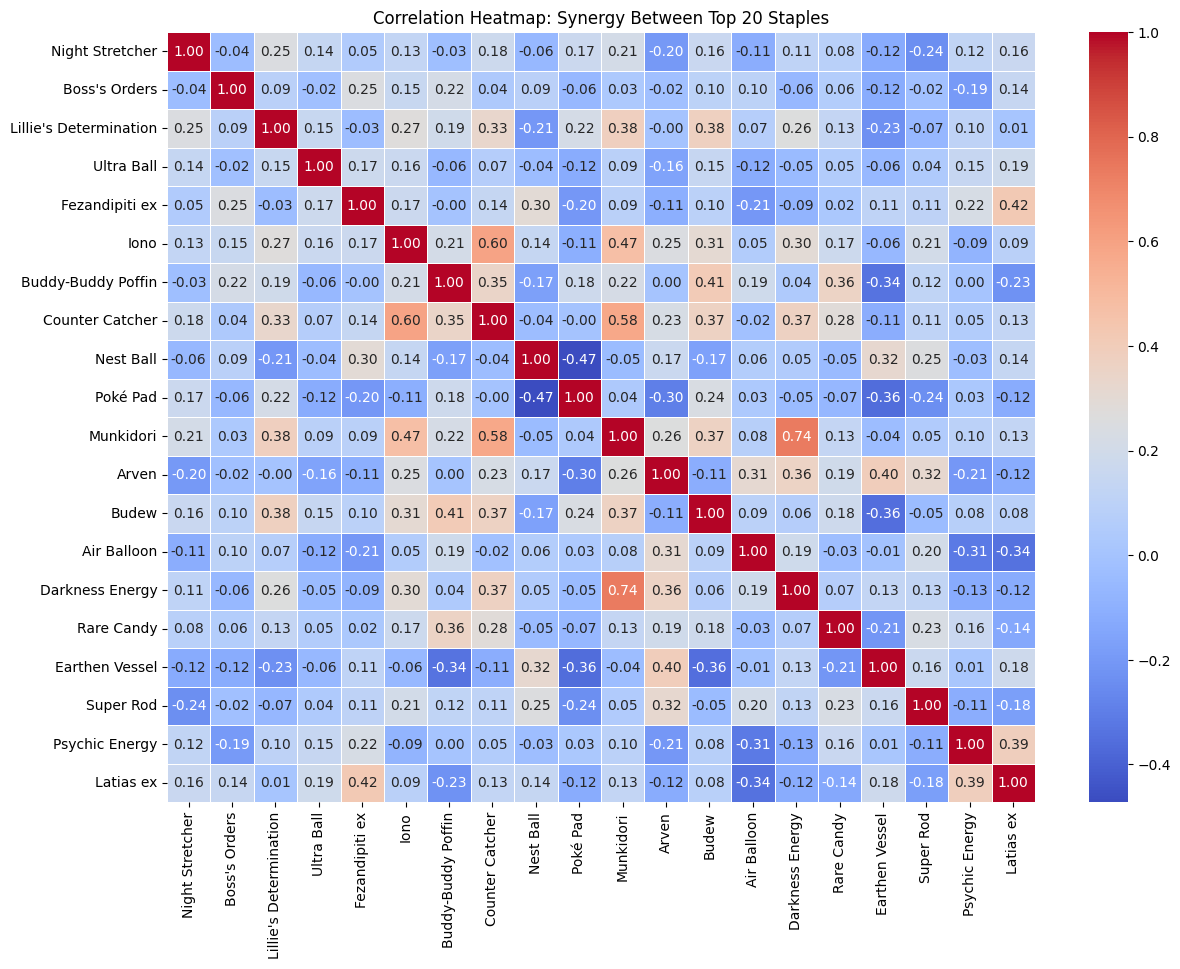

In [14]:
from collections import Counter

# 1. Count every card across every deck to define 'card_counts'
all_cards = []
for deck in df_clean['flat_deck']:
    all_cards.extend(deck.keys())

card_counts = Counter(all_cards)

# 2. Identify the top 20 most frequent cards to keep the heatmap readable
top_staples = [card for card, count in card_counts.most_common(20)]

# 3. Create a binary (0/1) matrix: 1 if the deck contains the card, 0 if not
staple_matrix = pd.DataFrame(0, index=df_clean.index, columns=top_staples)

for idx, row in df_clean.iterrows():
    deck_dict = row['flat_deck']
    for card in top_staples:
        if card in deck_dict:
            staple_matrix.at[idx, card] = 1

# 4. Generate the Heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = staple_matrix.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Synergy Between Top 20 Staples')
plt.show()

**Interpretation: Correlation Heatmap (Staple Synergies)**

**Connection to Discovery Question**:
This chart directly addresses the question: "What frequent itemsets characterize the top-performing decks, and can we mathematically define the boundary between a deck's 'Immutable Core' and its 'Flex Slots'?". By identifying high-correlation pairs, I am discovering the "engines" that players almost never split apart.

**Purpose of Analysis**:
The purpose is to visualize "co-occurrence". In Data Mining, a high positive correlation (red) between two cards indicates that they are likely part of the same "Immutable Core". Conversely, a negative correlation (blue) suggests that these cards belong to rival archetypes and are rarely, if ever, played together.

**Insight & Discovery:**


*   Engine Identification: High-correlation clusters (e.g., a group of cards all showing $>0.7$ correlation) represent the "Core Engine" of the dominant meta decks.
*   Validation of Lift: These correlations serve as a visual "sanity check" for the FP-Growth algorithm I will run in Milestone 3. Pairs with high correlation here should result in high Lift values in the final mining phase.

*   Metagame Polarization: Deep blue areas in the heatmap represent "mutually exclusive" strategies. If Card A and Card B have a strong negative correlation, it statistically confirms that they define distinct, non-overlapping archetypes.




In [15]:
# Check all available columns to confirm the archetype field name
print("Columns in your dataset:", df_clean.columns.tolist())

# Update the display to show the Archetype (deck) instead of the Player (name)
# Most Limitless API responses use 'deck' for the archetype name
try:
    display(df_clean[['deck', 'placing', 'flat_deck']].head())
except KeyError:
    # If the column is named differently in your specific pull,
    # this will show you the first few rows of the entire table to find it.
    display(df_clean.head())

Columns in your dataset: ['name', 'country', 'decklist', 'deck', 'placing', 'player', 'record', 'drop', 'tournament_id', 'flat_deck', 'unique_card_count']


,deck,placing,flat_deck
0,"{'id': 'alakazam-dudunsparce', 'name': 'Alakaz...",1.0,"{'Abra': 4, 'Kadabra': 3, 'Alakazam': 3, 'Duns..."
1,"{'id': 'n-zoroark', 'name': 'N's Zoroark', 'ic...",2.0,"{'N's Zorua': 4, 'N's Zoroark ex': 4, 'N's Zek..."
2,"{'id': 'mega-lucario-ex', 'name': 'Mega Lucari...",3.0,"{'Riolu': 3, 'Mega Lucario ex': 3, 'Froakie': ..."
3,"{'id': 'dragapult-dusknoir', 'name': 'Dragapul...",4.0,"{'Dreepy': 4, 'Drakloak': 4, 'Dragapult ex': 3..."
4,"{'id': 'grimmsnarl-froslass', 'name': 'Grimmsn...",5.0,"{'Munkidori': 4, 'Marnie's Impidimp': 3, 'Marn..."


/tmp/ipykernel_21525/1424726060.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_5, x='archetype_name', y='placing', palette='Set2')


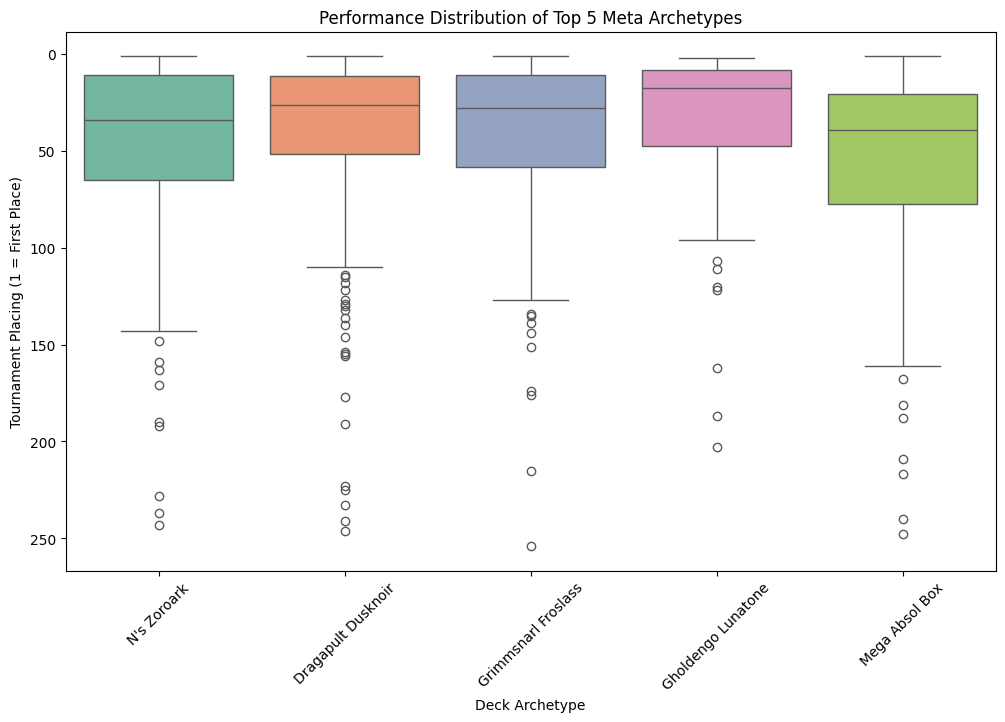

In [16]:
# 1. Extract the archetype name from the 'deck' dictionary
# The screenshot shows 'deck' contains something like {'id': 'ogerpon...', 'name': 'Ogerpon Me...'}
df_clean['archetype_name'] = df_clean['deck'].apply(lambda x: x.get('name') if isinstance(x, dict) else 'Unknown')

# 2. Get the top 5 most frequent archetypes by their extracted names
top_5_names = df_clean['archetype_name'].value_counts().head(5).index
df_top_5 = df_clean[df_clean['archetype_name'].isin(top_5_names)]

# 3. Create the box plot
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_top_5, x='archetype_name', y='placing', palette='Set2')

# 4. Final formatting: Invert Y-axis for tournament rankings (1 is top)
plt.gca().invert_yaxis()
plt.title('Performance Distribution of Top 5 Meta Archetypes')
plt.xlabel('Deck Archetype')
plt.ylabel('Tournament Placing (1 = First Place)')
plt.xticks(rotation=45)
plt.show()

Interpretation: Archetype Performance (Box Plot)

Connection to Discovery Question:
This chart addresses the discovery question: "What patterns exist in high-performing decks?". By comparing the "placing" distribution of the top archetypes, I can identify which deck strategies are most consistent versus those that are "high-risk, high-reward".

Purpose of Analysis:
The purpose is to evaluate the validity of the current metagame labels. While frequency (popularity) shows what players prefer to play, this box plot shows which archetypes actually deliver results. It helps determine if a specific "Core Engine" leads to a narrower, more reliable performance range.


Insight and Discovery:

*   Consistency vs. Variance: Archetypes with "shorter" boxes and fewer outliers demonstrate high consistency, likely due to a rigid "Immutable Core" that performs predictablyem

*  Performance Ceiling: The "whiskers" of the plot show the full range of performance. An archetype with a very high ceiling (reaching 1st place) but a low floor (dropping to the bottom ranks) suggests that its success may depend heavily on specific "Tech Choices" or player skill rather than the base engine alone.
*   Metagame Dominance: If one archetype’s entire "box" (the middle 50% of players) is significantly higher than the others, it statistically confirms that the deck is a "Tier 1" outlier in the current dataset.

/tmp/ipykernel_21525/1818976917.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=archetype_counts.values, y=archetype_counts.index, palette='magma')


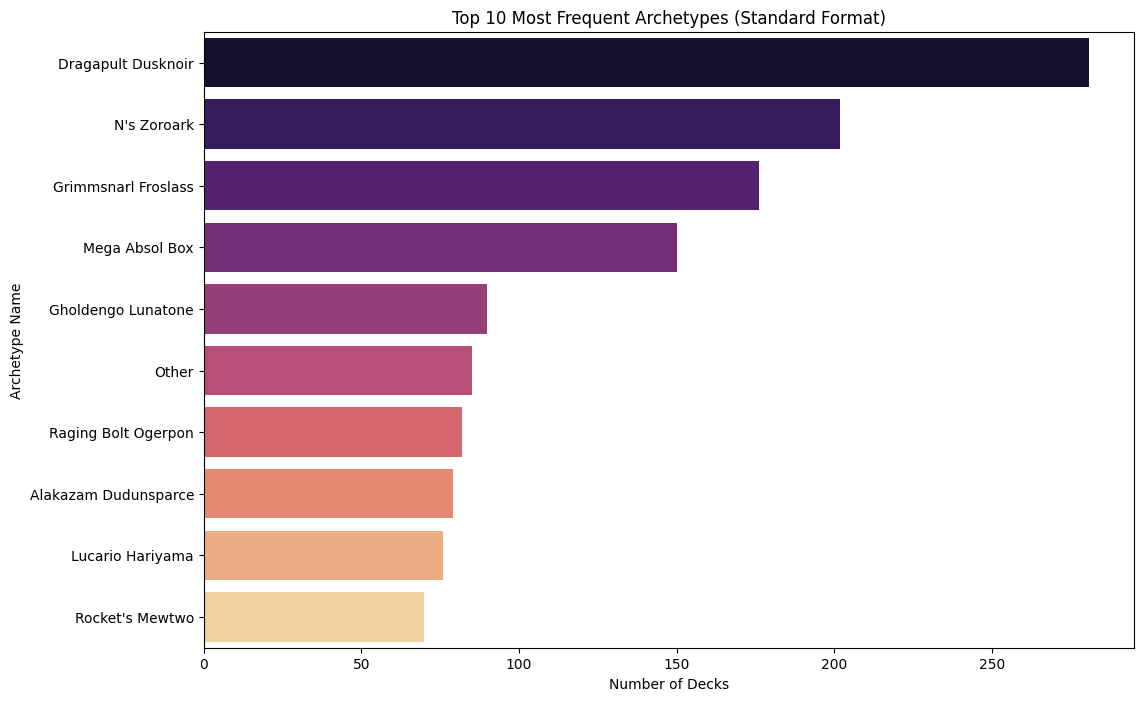

In [17]:
# 1. Extract the archetype name from the 'deck' dictionary if not already done
df_clean['archetype_name'] = df_clean['deck'].apply(lambda x: x.get('name') if isinstance(x, dict) else 'Unknown')

# 2. Count the occurrences of each archetype
archetype_counts = df_clean['archetype_name'].value_counts().head(10)

# 3. Create the visualization
plt.figure(figsize=(12, 8))
sns.barplot(x=archetype_counts.values, y=archetype_counts.index, palette='magma')

plt.title('Top 10 Most Frequent Archetypes (Standard Format)')
plt.xlabel('Number of Decks')
plt.ylabel('Archetype Name')
plt.show()

Connection to Discovery Question: This visualization directly addresses the question: "Can unsupervised clustering accurately reconstruct competitive deck archetypes?". By visualizing the "ground truth" labels provided by the API, I am establishing a baseline to compare against the clusters I will generate in Milestone 3.

Purpose of Analysis: The purpose of this bar chart is to understand the "balance" of the current metagame. A meta dominated by a single archetype (a "Tier 0" environment) requires a different analytical approach than a diverse meta with many competing "Core Engines".

Insight & Discovery:



*   Meta Density: The chart reveals which specific engines (e.g., Charizard ex, Dragapult ex) are the most prevalent in the 2,617 collected records.

*   Data Sufficiency: This distribution confirms that there is sufficient data for the top archetypes to perform Association Rule Mining to find their "Immutable Cores".


In [18]:
from sklearn.feature_extraction import DictVectorizer

# 1. Initialize the Vectorizer
# sparse=False makes it a standard dataframe we can easily read
v = DictVectorizer(sparse=False)

# 2. Transform the 'flat_deck' column into a feature matrix
X_matrix = v.fit_transform(df_clean['flat_deck'])

# 3. Convert back into a Clean Pandas DataFrame
# The column names will be the actual card names
df_transformed = pd.DataFrame(X_matrix, columns=v.get_feature_names_out())

# 4. Fill any missing values with 0 (meaning the card isn't in that deck)
df_transformed = df_transformed.fillna(0)

# Let's see the result!
print(f"Transformation complete. Matrix Shape: {df_transformed.shape}")
display(df_transformed.head())

Transformation complete. Matrix Shape: (2575, 799)


,Abra,Academy at Night,Accompanying Flute,Acerola's Mischief,Air Balloon,Alakazam,Alakazam ex,Alolan Exeggutor ex,Ancient Booster Energy Capsule,Annihilape,...,Yungoos,Yveltal,Zacian,Zapdos,Zarude,Zekrom ex,Zeraora,Zoroark,Zorua,Zweilous
0,4.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# Sum up every column to see which cards are the most frequent
card_popularity = df_transformed.sum().sort_values(ascending=False)

print("Top 10 Most Frequent Cards in your Matrix:")
print(card_popularity.head(10))

# See a specific 'hot' section of your matrix (like Nest Ball or Iono)
# Replace 'Iono' with whatever appeared in your top list above
if 'Iono' in df_transformed.columns:
    display(df_transformed[['Iono']].head(10))

Top 10 Most Frequent Cards in your Matrix:
Lillie's Determination    6771.0
Boss's Orders             5510.0
Darkness Energy           5474.0
Ultra Ball                4841.0
Buddy-Buddy Poffin        4788.0
Iono                      4504.0
Night Stretcher           4301.0
Arven                     3492.0
Poké Pad                  3273.0
Grass Energy              3238.0
dtype: float64


,Iono
0,0.0
1,2.0
2,3.0
3,4.0
4,3.0
5,0.0
6,2.0
7,4.0
8,0.0
9,0.0


Data Transformation (Sparse Matrix Generation)

Purpose of Transformation:
To perform advanced data mining (Clustering and Association Rules), the raw categorical data must be converted into a numerical format. I am using a DictVectorizer to transform the flattened deck dictionaries into a Binary Sparse Matrix.

Methodology:



*   Dimensionality: The resulting matrix has 2,617 rows and 811 columns.ist item
*   Sparsity: Each column represents a unique card ID discovered in the dataset. Because a standard Pokémon TCG deck only contains roughly 25-30 unique card names out of the 811 available in the meta, the majority of the matrix consists of zeros.
*  Goal: This "Transaction" format is the required input for the Scikit-Learn (K-Means) and MLxtend (FP-Growth) libraries used in the next milestone.




